# Drought Forecast — July Issues 2025–2026
Compare drought forecast month 7 (July issue) of 2025 vs 2026 at Tambon level:
1. load 2 drought forecast files + clean tambon geojson
2. data check — schema differs slightly per file
3. harmonize — same join key `CODE` for both years
4. check `TAMBON_IDN` vs `ADM3_PCODE` — how well the join key matches
5. fix mismatch
6. take max per Tambon — flagged >=1 month in 6 months = `risk` (same as `forecast-season` / `comparison`)
7. analysis — counts per year / change 2025 -> 2026 / province change
8. output geojson -> tableau

## Load data
- July 2025 = `202507droughtForecast_6month.xlsx` (single sheet ไม่มีปัญหา)
- July 2026 = `202607droughtForecast_6month.xlsx` (`Summary_drought` sheet ignored)

In [1]:
import pandas as pd
import geopandas as gpd
from pathlib import Path

FORECAST_DIR = Path('/Users/kbstudio/Library/CloudStorage/OneDrive-Personal/IECC/DroughtRiskArea_HII')
SHAPE_PATH = Path('/Users/kbstudio/Library/CloudStorage/OneDrive-Personal/IECC/TH_TAMBON_json/tha_admbnda_adm3_rtsd_20220121_geo.json')
OUTPUT_PATH = Path('/Users/kbstudio/Library/CloudStorage/OneDrive-Personal/Project/BAY/data-clean')
YEARS = [2025, 2026]

forecasts = {year: pd.read_excel(FORECAST_DIR / f'{year}07droughtForecast_6month.xlsx') for year in YEARS}
shapes = gpd.read_file(SHAPE_PATH)

for year in YEARS:
    print(f'{year}07 rows:', len(forecasts[year]))
print('Tambon polygons:', len(shapes))

202507 rows: 44328
202607 rows: 44328
Tambon polygons: 7425


## Data check
- check fields / months / `TYPE_E` of each file first — compare columns against the 2026 file (latest)

In [2]:
ref_cols = list(forecasts[2026].columns)
print('2026 columns:', ref_cols)
print()

for year in YEARS:
    df = forecasts[year]
    dup = df.loc[df.duplicated(['TAMBON_IDN', 'MONTH']), 'TAMBON_IDN'].unique()
    missing = [col for col in ref_cols if col not in df.columns]
    print(f'=== {year}07 ===')
    print('months:', sorted(df['MONTH'].unique()),
          '| unique tambons:', df['TAMBON_IDN'].nunique(),
          '| dup tambon in a month:', list(dup) if len(dup) else '-')
    print('missing columns vs 2026:', missing if missing else '-')
    print(df['TYPE_E'].value_counts().to_string())
    print()

2026 columns: ['TAMBON_IDN', 'TAMBON_T', 'TAMBON_E', 'AMPHOE_IDN', 'AMPHOE_T', 'AMPHOE_E', 'PROV_CODE', 'PROV_T', 'PROV_E', 'REGION_CODE', 'REGION', 'TYPE_T', 'TYPE_E', 'YEAR', 'MONTH']

=== 202507 ===
months: [np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)] | unique tambons: 7387 | dup tambon in a month: [np.int64(200701)]
missing columns vs 2026: ['REGION_CODE', 'REGION']
TYPE_E
norisk     42394
drought     1934

=== 202607 ===
months: [np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)] | unique tambons: 7387 | dup tambon in a month: [np.int64(200701)]
missing columns vs 2026: -
TYPE_E
norisk     40107
drought     4221



## Harmonize
- key `TAMBON_IDN` (7,387 tambons x 6 months)
- both years use the same labels `norisk` / `drought` — no relabel needed (unlike flood's `inundation`)
- 2026 has extra `REGION_CODE` / `REGION` columns — not needed, ignore
- tambon `200701` duplicated 2 rows per month (same as flood files) — take max with groupby handles it

-> create `CODE` as string so both years share the same join key

In [3]:
for df in forecasts.values():
    df['CODE'] = df['TAMBON_IDN'].astype(str)

for year in YEARS:
    print(f'{year} TYPE_E ->', sorted(forecasts[year]['TYPE_E'].unique()))

2025 TYPE_E -> ['drought', 'norisk']
2026 TYPE_E -> ['drought', 'norisk']


## Check TAMBON_IDN vs ADM3_PCODE
- compare codes against shapes (ตัด `TH` prefix ใน `adm3_pcode`)

In [4]:
shapes['CODE'] = shapes['ADM3_PCODE'].str.removeprefix('TH')
shape_codes = set(shapes['CODE'])

orphan_codes = set()
for year in YEARS:
    codes = set(forecasts[year]['CODE'])
    orphans = sorted(codes - shape_codes)
    orphan_codes |= set(orphans)
    print(f'{year}07 matched: {len(codes & shape_codes)} | orphan: {orphans}')

202507 matched: 7381 | orphan: ['201201', '401050', '530407', '630191', '810150', '860805']
202607 matched: 7381 | orphan: ['201201', '401050', '530407', '630191', '810150', '860805']


## Fix mismatch
- copy from flood forecast
- same 6 orphan codes as the flood forecast files, same in both years
- remap each to the nearest tambon code in the same amphoe (same method as `forecast-season` / `comparison`)
- codes only in shapes need nothing — they become no risk on merge

In [5]:
def nearest_shape_code(row):
    same_amphoe = shapes.loc[(shapes['CODE'].str[:2] == row['CODE'][:2])
                             & (shapes['ADM2_TH'] == row['AMPHOE_T']), 'CODE']
    last2 = int(row['CODE'][-2:])
    return min(same_amphoe, key=lambda code: abs(int(code[-2:]) - last2))


orphans = forecasts[2026][forecasts[2026]['CODE'].isin(orphan_codes)].drop_duplicates('CODE')
remap = {row['CODE']: nearest_shape_code(row) for _, row in orphans.iterrows()}
for df in forecasts.values():
    df['CODE'] = df['CODE'].replace(remap)

print('Re-mapped orphan forecast codes (both years):')
for old, new in remap.items():
    print(f'  {old} -> {new}')

Re-mapped orphan forecast codes (both years):
  201201 -> 200401
  401050 -> 401017
  530407 -> 530406
  630191 -> 630115
  810150 -> 810118
  860805 -> 860804


## Take max per Tambon
- each year: tambon flagged `drought` >=1 month (in 6 months) = `risk`
- groupby `CODE` + `any()` -> handles both the dup tambon (`200701`) and remapped codes
- wide table: row = tambon, column = year, value = risk (True/False)

In [6]:
def take_max(df, type_label):
    return df.assign(flag=df['TYPE_E'].eq(type_label)).groupby('CODE')['flag'].any()


drought_wide = pd.DataFrame({year: take_max(forecasts[year], 'drought') for year in YEARS}).fillna(False)

print('Tambons:', len(drought_wide))
drought_wide.head()

Tambons: 7381


,2025,2026
CODE,,
100101,False,False
100102,False,False
100103,False,False
100104,False,False
100105,False,False


## tambons at risk per year
- overall picture first: how many tambons at drought risk in each July issue

YEAR
2025    1442
2026    1802


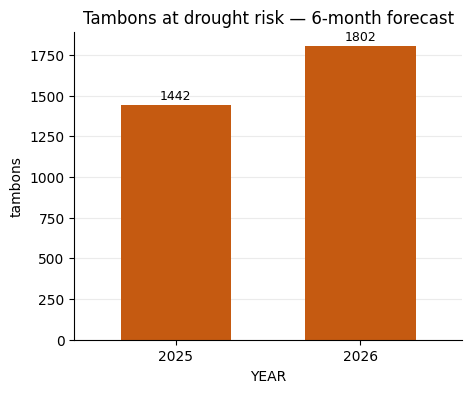

In [7]:
import matplotlib.pyplot as plt

DROUGHT_COLOR = '#C55A11'
NO_RISK_COLOR = '#EEEEEE'

counts = drought_wide.sum()
counts.index.name = 'YEAR'
print(counts.to_string())

ax = counts.plot.bar(color=DROUGHT_COLOR, figsize=(5, 4), width=0.6, rot=0)
ax.set_title('Tambons at drought risk — 6-month forecast')
ax.set_ylabel('tambons')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.25)
ax.set_axisbelow(True)
for container in ax.containers:
    ax.bar_label(container, padding=2, fontsize=9)

## tambon change 2025 -> 2026
- classify each tambon: `added` = risk only 2026, `removed` = risk only 2025, `stayed` = risk both years, `none` = neither

In [8]:
def classify_change(prev, cur):
    if prev and cur:
        return 'stayed'
    if cur:
        return 'added'
    if prev:
        return 'removed'
    return 'none'


change = pd.Series([classify_change(p, c) for p, c in zip(drought_wide[2025], drought_wide[2026])],
                   index=drought_wide.index, name='CHANGE')

print(change.value_counts().reindex(['stayed', 'added', 'removed', 'none']).to_string())

CHANGE
stayed     1093
added       709
removed     349
none       5230


## which provinces changed most
- net change per province: tambons at risk 2026 minus 2025 — where did the risk move

In [9]:
code_to_prov = shapes.set_index('CODE')['ADM1_EN']

by_prov = drought_wide.groupby(code_to_prov).sum()
prov_change = (by_prov[2026] - by_prov[2025]).sort_values()
print('=== Drought — top increase ===')
print(prov_change.tail(5)[::-1].to_string())
print('--- top decrease ---')
print(prov_change.head(5).to_string())

=== Drought — top increase ===
ADM1_EN
Maha Sarakham        63
Roi Et               55
Phitsanulok          48
Buri Ram             46
Nakhon Ratchasima    45
--- top decrease ---
ADM1_EN
Trang              -57
Sa Kaeo            -46
Kanchanaburi       -25
Ubon Ratchathani   -20
Trat               -17


## Maps — risk per year
- take max: `risk` = orange, `no risk` = grey (same layout as `forecast-season`)

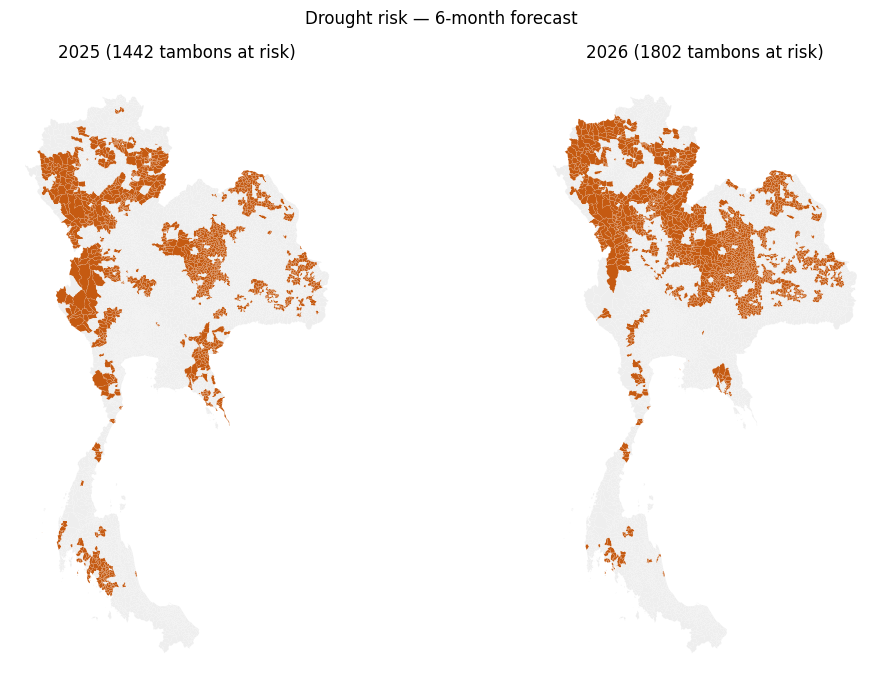

In [10]:
def plot_years(wide, risk_color, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 7))
    for ax, year in zip(axes, YEARS):
        layer = shapes.assign(RISK=shapes['CODE'].map(wide[year]).eq(True))
        layer.plot(ax=ax, color=layer['RISK'].map({True: risk_color, False: NO_RISK_COLOR}),
                   edgecolor='white', linewidth=0.05)
        ax.set_title(f'{year} ({int(wide[year].sum())} tambons at risk)')
        ax.axis('off')
    fig.suptitle(title, y=0.98)
    fig.tight_layout()


plot_years(drought_wide, DROUGHT_COLOR, 'Drought risk — 6-month forecast')

## Map — change 2025 -> 2026
- `stayed` = dark brown (persistent risk), `added` = orange (new in 2026), `removed` = light blue (risk gone)

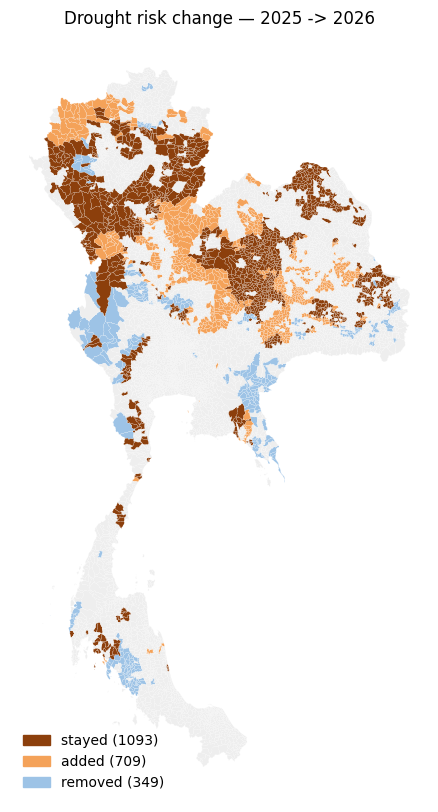

In [13]:
from matplotlib.patches import Patch

CHANGE_COLORS = {'stayed': '#8C3F0C', 'added': '#F4A259', 'removed': '#9DC3E6', 'none': NO_RISK_COLOR}

layer = shapes.assign(CHANGE=shapes['CODE'].map(change).fillna('none'))
ax = layer.plot(color=layer['CHANGE'].map(CHANGE_COLORS), figsize=(8, 10), edgecolor='white', linewidth=0.1)
ax.set_title('Drought risk change — 2025 -> 2026')
ax.axis('off')

n = change.value_counts()
ax.legend(handles=[Patch(color=CHANGE_COLORS[c], label=f'{c} ({n.get(c, 0)})')
                   for c in ['stayed', 'added', 'removed']],
          loc='lower left', frameon=False)

## Output geojson
- one file: `RISK_2025` / `RISK_2026` (`risk` / `no risk`) + `CHANGE` -> tableau

In [12]:
out = shapes[['ADM3_PCODE', 'ADM3_EN', 'ADM3_TH', 'ADM2_EN', 'ADM1_EN', 'CODE', 'geometry']].copy()
for year in YEARS:
    risk = out['CODE'].map(drought_wide[year]).eq(True)
    out[f'RISK_{year}'] = risk.map({True: 'risk', False: 'no risk'})
out['CHANGE'] = out['CODE'].map(change).fillna('none')
out = out.drop(columns='CODE')

output_file = OUTPUT_PATH / 'drought07_risk.geojson'
out.to_file(output_file, driver='GeoJSON', COORDINATE_PRECISION=8)
print(f'{output_file.name}: {len(out)} features ({output_file.stat().st_size / 1e6:.1f} MB)')

drought07_risk.geojson: 7425 features (8.5 MB)
